In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

We use the Standardized Mean Difference (SMD) to evaluate covariate balance between the Treatment and Control groups.

The formula is:

$$
\text{SMD}
=
\frac{\bar{X}_T-\bar{X}_C}
{\sqrt{\frac{s_T^2+s_C^2}{2}}}
$$

where:

- $\bar{X}_T$ = mean of the covariate in the Treatment group
- $\bar{X}_C$ = mean of the covariate in the Control group
- $s_T^2$ = variance of the covariate in the Treatment group
- $s_C^2$ = variance of the covariate in the Control group

The denominator is:

$$
\sqrt{\frac{s_T^2+s_C^2}{2}}
$$

It provides a common scale for standardizing the difference in means.

SMD is mainly used as a **balance diagnostic**, rather than as a hypothesis test.

A common rule of thumb is:

$$
|\text{SMD}| < 0.1
$$

which suggests reasonably good covariate balance between the two groups.

In [12]:
def standardized_mean_difference(df, treatment_col, covariates):
    rows = []
    for col in covariates:
        t = df.loc[df[treatment_col]==1, col]
        c = df.loc[df[treatment_col]==0, col]
        pooled_sd = np.sqrt((t.var(ddof=1)+c.var(ddof=1))/2)
        smd = (t.mean() - c.mean())/pooled_sd if pooled_sd > 0 else 0.0
        rows.append({
            "covariate": col,
            "treatment_mean": t.mean(),
            "control_mean": c.mean(),
            "SMD": smd
        })
    return pd.DataFrame(rows)


def fit_propensity_score(df, treatment_col, covariates, score_col="propensity_score"):
    model = LogisticRegression(max_iter=1000)
    model.fit(df[covariates], df[treatment_col])
    out = df.copy()
    out[score_col] = model.predict_proba(out[covariates])[:, 1]
    return out, model

def nearest_neighbor_match(df, treatment_col, score_col="propensity_score", replace=True):
    treated = df[df[treatment_col] == 1].copy()
    control = df[df[treatment_col] == 0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[[score_col]])
    distances, indices = nn.kneighbors(treated[[score_col]])
    # indices[i] = 第 i 个 treated observation 匹配到的 control observation 的位置。

    matched_control = control.iloc[indices.flatten()].copy()

    treated = treated.reset_index(drop=False).rename(
        columns={"index":"original_index"}
    )
    matched_control = matched_control.reset_index(drop=False).rename(
        columns={"index":"original_index"}
    )

    treated["pair_id"] = range(len(treated))
    matched_control["pair_id"] = range(len(matched_control))

    treated["match_group"] = "treated"
    matched_control["match_group"] = "control"


    matched = pd.concat(
        [treated, matched_control],
        axis = 0,
        ignore_index =True
        )

    return matched, distances.flatten()


def att_from_matched_pairs(matched, outcome_col):
    treated = (
        matched.loc[matched["match_group"] == "treated", ["pair_id", outcome_col]]
        .set_index("pair_id")[outcome_col]
    )

    control = (
        matched.loc[matched["match_group"] == "control", ["pair_id", outcome_col]]
        .set_index("pair_id")[outcome_col]
    )

    pair_diff = treated - control

    return pair_diff.mean()



# Scenario 1: A/B test with compromised randomization / selection bias

#### Context

Suppose we wants to test a new **in-app safety education prompt** intended to increase 28-day completed trips.

The experiment was intended to be randomized, but a rollout bug causes high-activity users and users in certain markets to be more likely to actually enter the Treatment arm.

Now Treatment and Control differ systematically **before treatment**.

A raw Treatment-Control comparison mixes:

- the causal treatment effect
- pre-existing differences in user activity and market mix

We will simulate this as a **compromised experiment** and then use PSM as a salvage / sensitivity analysis.

#### Creating Selection Bias using simulation

The goal of this simulation is to create a setting where the **true treatment effect is known**, but Treatment and Control are not comparable because treatment assignment is influenced by pre-treatment user characteristics.

This allows us to test whether Propensity Score Matching can reduce the bias.

##### Step 1: Create pre-treatment user characteristics

We first simulate several user-level variables that exist before treatment:

- `prior_trips`: historical trip activity
- `prior_revenue`: historical revenue
- `market_high_demand`: whether the user is in a high-demand market
- `tenure_months`: how long the user has been on the platform

These variables will affect both:

1. the probability of receiving treatment, and
2. the final outcome.

This is what creates confounding.

##### Step 2: Create non-random treatment assignment

Instead of assigning every user to Treatment with the same probability, we make treatment probability depend on the pre-treatment variables.

Conceptually:

$$
P(T=1 \mid X)
=
f(\text{prior trips, prior revenue, market, tenure})
$$

We first calculate a linear score:

$$
\text{logit}
=
-1
+0.12(\text{prior trips})
+0.006(\text{prior revenue})
+0.7(\text{high-demand market})
+0.01(\text{tenure})
$$

We then transform the logit into a probability using the logistic function:

$$
P(T=1 \mid X)
=
\frac{1}{1+e^{-\text{logit}}}
$$

As a result, users with higher prior activity, revenue, or other favorable characteristics are more likely to enter Treatment.

Treatment assignment is therefore no longer random.

##### Step 3: Simulate the outcome

We define the post-treatment outcome as 28-day completed trips:

$$
Y
=
3
+0.65(\text{prior trips})
+0.008(\text{prior revenue})
+1.5(\text{high-demand market})
+0.02(\text{tenure})
+2(T)
+\epsilon
$$

where:

- $T$ = actual treatment status
- the true causal treatment effect is set to **+2 trips**
- $\epsilon$ represents random noise

The term

$$
2(T)
$$

is the true treatment effect.

##### Step 4: Where does selection bias come from?

Selection bias is not represented by one single term in the outcome equation.

It is created because the same pre-treatment variables affect both:

$$
X \rightarrow T
$$

and

$$
X \rightarrow Y
$$

For example, `prior_trips` affects treatment assignment:

$$
\text{prior trips} \rightarrow P(T=1)
$$

but it also affects future trips:

$$
\text{prior trips} \rightarrow Y
$$

Therefore, Treatment users are more active even before receiving treatment.

If we directly compare:

$$
E[Y \mid T=1] - E[Y \mid T=0]
$$

the observed difference contains both:

$$
\text{Observed Difference}
=
\text{Treatment Effect}
+
\text{Selection Effect}
$$

In this simulation, the true causal treatment effect is known to be:

$$
\text{True Treatment Effect}=2
$$

If the raw Treatment-Control difference is much larger than 2, the extra difference is caused by selection bias.

##### Step 5: Why PSM is useful here

Propensity Score Matching attempts to construct a more comparable Control group by matching Treatment and Control users with similar probabilities of receiving treatment.

The propensity score is:

$$
e(X)=P(T=1 \mid X)
$$

After matching, we check whether the pre-treatment covariates are better balanced.

If matching works well, the estimated treatment effect should move closer to the known true effect of **+2 trips**.

In [ ]:
n = 12000

# trip count 是非负整数, lam=8表示平均历史 trip 数在 8 左右
prior_trips = np.random.poisson(lam=9, size=n)
# 用 lognormal，是因为 revenue 常常右偏，大部分人不高，少数 heavy users 很高
prior_revenue = np.random.lognormal(mean=4.2, sigma=0.6, size=n)
#  0/1 变量，35% 的用户属于高需求市场
market_high_demand = np.random.binomial(1, 0.35, size=n)
#  tenure 非负、右偏的连续变量
tenure_months = np.random.gamma(shape=3, scale=8, size=n)

# 50/50 randomization
intended_assignment = np.random.binomial(1, 0.5, size=n)

# implementation errors: assignment is impacted by confounders
# A confounder is a pre-treatment variable that affects both treatment assignment and the outcome.
logit = (
    -1.0
    + 0.12 * prior_trips
    + 0.006 * prior_revenue
    + 0.7 * market_high_demand
    + 0.01 * tenure_months
)

# logistic function: convert numbers to between 0 and 1
p_actual_treatment = 1/(1 + np.exp(-logit))
# simulate selection bias
actual_treatment = np.random.binomial(1, p_actual_treatment)

true_effect = 2.0
noise = np.random.normal(0, 3, size=n)

post_28d_trips = (
    3
    + 0.65 * prior_trips # confounders
    + 0.008 * prior_revenue
    + 1.5 * market_high_demand
    + 0.02 * tenure_months
    + true_effect * actual_treatment # treatment effect
    + noise
)

ab_biased = pd.DataFrame({
    "actual_treatment": actual_treatment,
    "prior_trip": prior_trips,
    "prior_revenue": prior_revenue,
    "market_high_demand": market_high_demand,
    "tenure_months": tenure_months,
    "post_28d_trips": post_28d_trips
})

ab_biased.head()


,actual_treatment,prior_trip,prior_revenue,market_high_demand,tenure_months,post_28d_trips
0,1,8,94.900120,1,10.864499,10.831128
1,0,6,42.213393,0,44.540277,8.017939
2,0,8,31.733134,0,11.360067,8.152152
3,1,7,69.513272,0,31.628975,9.874697
4,1,9,72.885516,1,10.276474,11.347743


In [8]:
covariates_1 = ["prior_trip", "prior_revenue", "market_high_demand", "tenure_months"]

balance_before_1 = standardized_mean_difference(
                        ab_biased, 
                        treatment_col = "actual_treatment",
                        covariates = covariates_1
                    )
balance_before_1

,covariate,treatment_mean,control_mean,SMD
0,prior_trip,9.283117,8.267895,0.349081
1,prior_revenue,82.919779,69.551380,0.274188
2,market_high_demand,0.397054,0.269405,0.273295
3,tenure_months,24.351608,22.563399,0.132669


In [9]:
raw_effect_1 = (
    ab_biased.loc[ab_biased["actual_treatment"]==1, "post_28d_trips"].mean()
    - ab_biased.loc[ab_biased["actual_treatment"]==0, "post_28d_trips"].mean()
)

print("True treatment effect:", true_effect)
print("Raw biased comparison:", round(raw_effect_1, 3))

True treatment effect: 2.0
Raw biased comparison: 3.056


The raw estimate will generally be biased upward because Treatment contains more high-activity / high-value users even before treatment.

In [13]:
# 用 covariates_1 里的 pre-treatment variables，预测每个人进入 actual_treatment = 1 的概率。
ab_biased_ps, ps_model_1 = fit_propensity_score(
    ab_biased,
    treatment_col="actual_treatment",
    covariates=covariates_1
)

# 对每一个 Treatment user，找一个 propensity score 最接近的 Control user。
matched_1, distances_1 = nearest_neighbor_match(
    ab_biased_ps,
    treatment_col="actual_treatment",
    score_col="propensity_score"
)

# 创建一个新的 0/1 treatment indicator。
matched_1["matched_treatment"] = (matched_1["match_group"] == "treated").astype(int)

balance_after_1 = standardized_mean_difference(
    matched_1,
    treatment_col="matched_treatment",
    covariates=covariates_1
)

psm_effect_1 = att_from_matched_pairs(matched_1, "post_28d_trips")

print("True treatment effect:", true_effect)
print("Raw biased comparison:", round(raw_effect_1, 3))
print("PSM estimate:", round(psm_effect_1, 3))

print("\nBalance before matching:")
display(balance_before_1)

print("\nBalance after matching:")
display(balance_after_1)


True treatment effect: 2.0
Raw biased comparison: 3.056
PSM estimate: 2.089

Balance before matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_trip,9.283117,8.267895,0.349081
1,prior_revenue,82.919779,69.551380,0.274188
2,market_high_demand,0.397054,0.269405,0.273295
3,tenure_months,24.351608,22.563399,0.132669



Balance after matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_trip,9.283117,9.308321,-0.008430
1,prior_revenue,82.919779,81.572719,0.025135
2,market_high_demand,0.397054,0.395673,0.002823
3,tenure_months,24.351608,24.732700,-0.027252


If an important confounder is omitted, PSM cannot balance it, and the treatment effect estimate can remain biased.

## Evaluate the PSM Result

The purpose of Propensity Score Matching is to make the Treatment and Control groups more comparable on observed pre-treatment characteristics.

Therefore, we should not evaluate PSM primarily based on how well the logistic regression predicts treatment assignment.

Instead, we evaluate whether matching successfully improves **covariate balance** and creates comparable Treatment and Control groups.

### 1. Compare the raw estimate with the PSM estimate

Because this is a simulation, we know the true treatment effect:

$$
\text{True Treatment Effect} = 2
$$

Before matching, the raw Treatment-Control comparison contains both:

$$
\text{Observed Difference}
=
\text{Treatment Effect}
+
\text{Selection Effect}
$$

Therefore, the raw estimate may be biased away from 2.

After matching, if PSM successfully reduces selection bias, the estimated ATT should move closer to the true effect.

In this simulation, we compare:

- True treatment effect
- Raw Treatment-Control difference
- PSM-adjusted ATT

A PSM estimate substantially closer to the true effect suggests that matching successfully reduced the observed selection bias.

---

### 2. Check covariate balance using SMD

For each pre-treatment covariate, we calculate the Standardized Mean Difference:

$$
\text{SMD}
=
\frac{\bar{X}_T-\bar{X}_C}
{\sqrt{\frac{s_T^2+s_C^2}{2}}}
$$

The goal is for matching to move SMD values closer to zero.

A commonly used rule of thumb is:

$$
|\text{SMD}| < 0.1
$$

after matching.

We should compare SMD both **before and after matching**.

A successful matching procedure should substantially reduce the absolute SMD for the important confounders.

---

### 3. Check propensity-score overlap

Treatment and Control observations should have sufficient overlap in their propensity-score distributions.

If Treatment and Control occupy completely different propensity-score ranges, good matches do not exist.

Good overlap means that, for most treated units, there are comparable Control units with similar propensity scores.

Poor overlap suggests a violation of the common-support / positivity assumption and makes the causal estimate less reliable.

---

### 4. Check matching distance

For 1-to-1 nearest-neighbor matching on one propensity score, the matching distance is:

$$
|PS_T - PS_C|
$$

Smaller distances indicate better matches.

We should examine:

- Mean matching distance
- Median matching distance
- Maximum matching distance
- High-percentile matching distance, such as the 95th percentile

Very large matching distances indicate that some treated observations do not have good comparable Controls.

---

### 5. Check how many observations are retained and reused

If matching uses a caliper, some treated users may not find an acceptable Control match and will be dropped.

If matching is performed with replacement, the same Control user may be matched to multiple Treatment users.

Therefore, we should monitor:

- Number of treated users
- Number of matched treated users
- Number of unique matched Controls
- Control reuse rate
- Percentage of treated users successfully matched

These diagnostics help us understand the effective sample supporting the ATT estimate.

===== Treatment Effect =====
True treatment effect: 2.0
Raw biased comparison: 3.056
PSM estimate: 2.089

===== Covariate Balance =====


,covariate,SMD_before,SMD_after,abs_SMD_before,abs_SMD_after
0,prior_trip,0.349081,-0.008430,0.349081,0.008430
1,prior_revenue,0.274188,0.025135,0.274188,0.025135
2,market_high_demand,0.273295,0.002823,0.273295,0.002823
3,tenure_months,0.132669,-0.027252,0.132669,0.027252


All covariates balanced after matching: True

===== Matching Distance =====
Mean distance: 0.0002
Median distance: 0.0
95th percentile distance: 0.0004
Max distance: 0.0418

===== Matched Sample =====
Matched treated observations: 8689
Matched control observations: 8689
Unique control observations: 2513
Control reuse ratio: 3.458


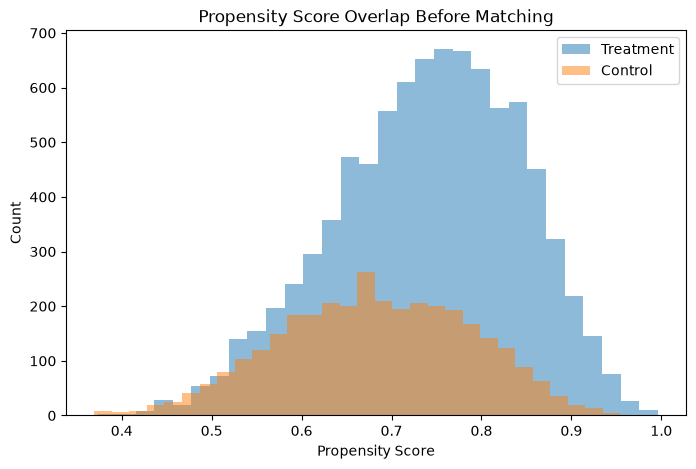

In [17]:
# =========================================================
# PSM Evaluation
# =========================================================

# 1. Treatment effect comparison
print("===== Treatment Effect =====")
print("True treatment effect:", round(true_effect, 3))
print("Raw biased comparison:", round(raw_effect_1, 3))
print("PSM estimate:", round(psm_effect_1, 3))


# ---------------------------------------------------------
# 2. Covariate balance
# ---------------------------------------------------------

balance_comparison = (
    balance_before_1[["covariate", "SMD"]]
    .rename(columns={"SMD": "SMD_before"})
    .merge(
        balance_after_1[["covariate", "SMD"]]
        .rename(columns={"SMD": "SMD_after"}),
        on="covariate"
    )
)

balance_comparison["abs_SMD_before"] = balance_comparison["SMD_before"].abs()
balance_comparison["abs_SMD_after"] = balance_comparison["SMD_after"].abs()

print("\n===== Covariate Balance =====")
display(balance_comparison)

print(
    "All covariates balanced after matching:",
    (balance_comparison["abs_SMD_after"] < 0.1).all()
)


# ---------------------------------------------------------
# 3. Matching distance
# ---------------------------------------------------------

print("\n===== Matching Distance =====")

print("Mean distance:",
      round(np.mean(distances_1), 4))

print("Median distance:",
      round(np.median(distances_1), 4))

print("95th percentile distance:",
      round(np.quantile(distances_1, 0.95), 4))

print("Max distance:",
      round(np.max(distances_1), 4))


# ---------------------------------------------------------
# 4. Matched sample diagnostics
# ---------------------------------------------------------

treated_matched = matched_1[
    matched_1["match_group"] == "treated"
]

control_matched = matched_1[
    matched_1["match_group"] == "control"
]

print("\n===== Matched Sample =====")

print("Matched treated observations:",
      len(treated_matched))

print("Matched control observations:",
      len(control_matched))

# If original_index exists in your matching function:
if "original_index" in control_matched.columns:

    unique_controls = control_matched["original_index"].nunique()

    print("Unique control observations:",
          unique_controls)

    print(
        "Control reuse ratio:",
        round(len(control_matched) / unique_controls, 3)
    )


# ---------------------------------------------------------
# 5. Propensity-score overlap
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    ab_biased_ps.loc[
        ab_biased_ps["actual_treatment"] == 1,
        "propensity_score"
    ],
    bins=30,
    alpha=0.5,
    label="Treatment"
)

plt.hist(
    ab_biased_ps.loc[
        ab_biased_ps["actual_treatment"] == 0,
        "propensity_score"
    ],
    bins=30,
    alpha=0.5,
    label="Control"
)

plt.xlabel("Propensity Score")
plt.ylabel("Count")
plt.title("Propensity Score Overlap Before Matching")
plt.legend()

plt.show()

## How to Evaluate Propensity Score Matching in Practice

A propensity-score model is different from a traditional prediction model.

The goal is **not** to maximize prediction accuracy, AUC, F1 score, or classification accuracy.

The purpose of the propensity model is to create Treatment and Control groups that are comparable on observed pre-treatment covariates.

Therefore:

> A good propensity-score model is a model that produces good covariate balance and sufficient overlap — not necessarily one that best predicts Treatment.

### 1. Covariate Balance — Most Important

Check the balance of important pre-treatment confounders before and after matching.

A common diagnostic is the absolute Standardized Mean Difference:

$$
|\text{SMD}|
$$

A commonly used guideline is:

$$
|\text{SMD}| < 0.1
$$

after matching.

The important question is:

> Did matching make Treatment and Control similar on the variables that could confound the treatment effect?

---

### 2. Common Support / Propensity Score Overlap

Plot the propensity-score distributions of Treatment and Control.

There should be substantial overlap.

If Treatment observations have propensity scores near 1 while Control observations have scores near 0, comparable matches may not exist.

A model with extremely high predictive accuracy can actually indicate poor overlap.

For example:

- Treatment scores: 0.90–1.00
- Control scores: 0.00–0.10

may produce excellent classification accuracy but very poor causal comparability.

Therefore, a high AUC is **not the objective** of propensity-score modeling.

---

### 3. Matching Quality

For nearest-neighbor matching, inspect the distance between matched propensity scores.

Good matches should have small distances.

Consider checking:

- Mean distance
- Median distance
- 95th percentile distance
- Maximum distance

A caliper can be used to prevent very poor matches.

---

### 4. Sample Retention and Matching Structure

Check how much data remains after matching.

For matching without replacement:

- each Control can be used at most once.

For matching with replacement:

- the same Control may be matched to multiple treated observations.

Evaluate:

- matched sample size
- percentage of treated units matched
- number of unique Controls
- amount of Control reuse

---

### 5. Confounder Coverage

PSM can only balance variables that are observed and included in the propensity model.

The key assumption is that the important variables affecting both Treatment assignment and the outcome have been measured.

If an important confounder is omitted:

$$
X \rightarrow T
$$

and

$$
X \rightarrow Y
$$

PSM cannot balance that variable, and the estimated treatment effect may remain biased.

Therefore, selecting the right pre-treatment confounders is often more important than tuning the logistic-regression model.

---

### 6. When is the Propensity Model "Good Enough"?

There is no universal AUC threshold.

Instead, stop modifying the propensity model when:

1. Important covariates are adequately balanced after matching.
2. Propensity-score overlap is sufficient.
3. Matching distances are reasonably small.
4. Enough observations remain to support the target estimand.
5. The matching procedure is stable under reasonable alternative specifications.

If balance remains poor, consider:

- adding important confounders
- adding nonlinear terms or interactions
- changing the matching algorithm
- using a caliper
- changing the matching ratio
- using weighting instead of matching

The objective is **balance**, not prediction performance.


# Scenario 2) Valid A/B test, but we only want the effect among users who actually received treatment

Suppose the App randomly assigns users to a new **support intervention**.

- Assignment is truly randomized.
- But only some Treatment-assigned users actually reach the screen and receive the intervention.
- Reaching that screen depends on pre-treatment user characteristics such as historical support usage and activity.

Now the subgroup `received_treatment = 1` is **not random**, even though original assignment was random.

If we insist on estimating the effect among actual recipients, we have an observational-style comparison problem.

> In real work, this is a stronger-assumption analysis. PSM does **not** automatically recover a causal effect if treatment receipt depends on unobserved post-randomization factors.


In [ ]:

n = 15000

prior_trips = np.random.poisson(lam=7, size=n)
prior_support_contacts = np.random.poisson(lam=1.2, size=n)
prior_revenue = np.random.lognormal(mean=4.0, sigma=0.7, size=n)
tenure_months = np.random.gamma(shape=2.5, scale=10, size=n)

# True randomized assignment
assignment = np.random.binomial(1, 0.5, size=n)

# Treatment receipt among assigned users depends only on observed PRE-treatment variables
# 一个已经被 assign 到 Treatment 的用户，最后有多大概率真的 receive treatment。
# 比如历史更活跃、support contact 更多、revenue 更高的人，更容易真正走到 treatment。
receipt_logit = (
    -1.8
    + 0.15 * prior_support_contacts
    + 0.08 * prior_trips
    + 0.004 * prior_revenue
)

# 把 logit 转成每个人自己的 treatment-receipt probability。
p_receipt = 1 / (1 + np.exp(-receipt_logit))
# 模拟这个人是否receive treatment，只有treatment有资格接受treatment
received_treatment = assignment * np.random.binomial(1, p_receipt)

# True effect among those who actually receive treatment
true_effect_received = 3.0
noise = np.random.normal(0, 3.5, size=n)

# outcome metric 同时受到 baseline characteristics 和 actual treatment receipt 的影响。
post_28d_trips = (
    2.5
    + 0.7 * prior_trips
    + 0.4 * prior_support_contacts
    + 0.006 * prior_revenue
    + 0.015 * tenure_months
    + true_effect_received * received_treatment
    + noise
)

receipt_df = pd.DataFrame({
    "assignment": assignment,
    "received_treatment": received_treatment,
    "prior_trips": prior_trips,
    "prior_support_contacts": prior_support_contacts,
    "prior_revenue": prior_revenue,
    "tenure_months": tenure_months,
    "post_28d_trips": post_28d_trips
})

receipt_df.head()


,assignment,received_treatment,prior_trips,prior_support_contacts,prior_revenue,tenure_months,post_28d_trips
0,1,0,6,0,110.858773,10.242339,12.436429
1,1,0,6,0,141.457006,65.964765,3.016104
2,0,0,11,0,69.966534,14.331904,7.242173
3,1,0,11,1,22.950391,16.348708,5.411133
4,0,0,6,2,29.404987,45.494905,5.003142


In [19]:

# Compare actual recipients against users who did not receive treatment
# This naive comparison is confounded because recipients are systematically different.
naive_effect_2 = (
    receipt_df.loc[receipt_df["received_treatment"] == 1, "post_28d_trips"].mean()
    - receipt_df.loc[receipt_df["received_treatment"] == 0, "post_28d_trips"].mean()
)

print("True receipt effect:", true_effect_received)
print("Naive recipient vs non-recipient comparison:", round(naive_effect_2, 3))


True receipt effect: 3.0
Naive recipient vs non-recipient comparison: 3.448


In [20]:

covariates_2 = ["prior_trips", "prior_support_contacts", "prior_revenue", "tenure_months"]

balance_before_2 = standardized_mean_difference(
    receipt_df,
    treatment_col="received_treatment",
    covariates=covariates_2
)

balance_before_2


,covariate,treatment_mean,control_mean,SMD
0,prior_trips,7.392432,6.954538,0.165000
1,prior_support_contacts,1.321003,1.173941,0.132720
2,prior_revenue,78.395211,67.446611,0.185288
3,tenure_months,25.555309,25.235239,0.019887


In [22]:

receipt_ps, ps_model_2 = fit_propensity_score(
    receipt_df,
    treatment_col="received_treatment",
    covariates=covariates_2
)

matched_2, distances_2 = nearest_neighbor_match(
    receipt_ps,
    treatment_col="received_treatment",
    score_col="propensity_score"
)

matched_2["matched_treatment"] = (matched_2["match_group"] == "treated").astype(int)

balance_after_2 = standardized_mean_difference(
    matched_2,
    treatment_col="matched_treatment",
    covariates=covariates_2
)

psm_effect_2 = att_from_matched_pairs(matched_2, "post_28d_trips")

print("True receipt effect:", true_effect_received)
print("Naive recipient comparison:", round(naive_effect_2, 3))
print("PSM estimate:", round(psm_effect_2, 3))

print("\nBalance before matching:")
display(balance_before_2)

print("\nBalance after matching:")
display(balance_after_2)


True receipt effect: 3.0
Naive recipient comparison: 3.448
PSM estimate: 3.045

Balance before matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_trips,7.392432,6.954538,0.165000
1,prior_support_contacts,1.321003,1.173941,0.132720
2,prior_revenue,78.395211,67.446611,0.185288
3,tenure_months,25.555309,25.235239,0.019887



Balance after matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_trips,7.392432,7.378401,0.005217
1,prior_support_contacts,1.321003,1.346088,-0.022066
2,prior_revenue,78.395211,77.625343,0.011893
3,tenure_months,25.555309,25.531405,0.001498



The assumptions in this scenario are stronger than in the first case.

PSM can help **only if the reasons users receive treatment are captured by observed pre-treatment variables**. 

If receipt depends on things like motivation, intent, or post-assignment behavior that we do not observe, PSM may still be biased. This is why actual-treatment-receipt analyses should be treated cautiously.

Normally we use ITT, LACE for this scenario instead.


# 3) No A/B test: observational adopters vs. non-adopters

Suppose we launches a new **Rider Membership feature** to everyone.

There is no experiment.

Users choose whether to adopt it.

You want to estimate whether adoption increases 28-day spend.

The problem is obvious:

- Heavy users are more likely to adopt.
- High-value users may already spend more even without the feature.

This is a classic observational PSM use case.


In [23]:

n = 20000

prior_28d_orders = np.random.poisson(lam=6, size=n)
prior_28d_revenue = np.random.lognormal(mean=4.1, sigma=0.7, size=n)
tenure_months = np.random.gamma(shape=3, scale=9, size=n)
urban_market = np.random.binomial(1, 0.6, size=n)

# Adoption is self-selected
adoption_logit = (
    -2.0
    + 0.18 * prior_28d_orders
    + 0.006 * prior_28d_revenue
    + 0.015 * tenure_months
    + 0.5 * urban_market
)

p_adopt = 1 / (1 + np.exp(-adoption_logit))
adopted = np.random.binomial(1, p_adopt)

# True causal effect of adoption = +$8 in next-28d revenue
true_adoption_effect = 8.0
noise = np.random.normal(0, 35, size=n)

post_28d_revenue = (
    15
    + 0.75 * prior_28d_revenue
    + 2.2 * prior_28d_orders
    + 0.3 * tenure_months
    + 5 * urban_market
    + true_adoption_effect * adopted
    + noise
)

obs_df = pd.DataFrame({
    "adopted": adopted,
    "prior_28d_orders": prior_28d_orders,
    "prior_28d_revenue": prior_28d_revenue,
    "tenure_months": tenure_months,
    "urban_market": urban_market,
    "post_28d_revenue": post_28d_revenue
})

obs_df.head()


,adopted,prior_28d_orders,prior_28d_revenue,tenure_months,urban_market,post_28d_revenue
0,0,3,31.259221,26.672979,1,44.916486
1,1,2,89.900305,26.707371,1,146.797132
2,0,7,115.489307,4.533806,1,77.629990
3,1,3,68.614645,47.039271,0,116.992747
4,0,7,34.791975,12.860798,1,99.824176


In [24]:

naive_effect_3 = (
    obs_df.loc[obs_df["adopted"] == 1, "post_28d_revenue"].mean()
    - obs_df.loc[obs_df["adopted"] == 0, "post_28d_revenue"].mean()
)

print("True adoption effect:", true_adoption_effect)
print("Naive adopter vs non-adopter comparison:", round(naive_effect_3, 3))


True adoption effect: 8.0
Naive adopter vs non-adopter comparison: 24.01


In [26]:

covariates_3 = ["prior_28d_orders", "prior_28d_revenue", "tenure_months", "urban_market"]

balance_before_3 = standardized_mean_difference(
    obs_df,
    treatment_col="adopted",
    covariates=covariates_3
)

obs_ps, ps_model_3 = fit_propensity_score(
    obs_df,
    treatment_col="adopted",
    covariates=covariates_3
)

matched_3, distances_3 = nearest_neighbor_match(
    obs_ps,
    treatment_col="adopted",
    score_col="propensity_score"
)

matched_3["matched_treatment"] = (matched_3["match_group"] == "treated").astype(int)

balance_after_3 = standardized_mean_difference(
    matched_3,
    treatment_col="matched_treatment",
    covariates=covariates_3
)

psm_effect_3 = att_from_matched_pairs(matched_3, "post_28d_revenue")

print("True adoption effect:", true_adoption_effect)
print("Naive comparison:", round(naive_effect_3, 3))
print("PSM estimate:", round(psm_effect_3, 3))

print("\nBalance before matching:")
display(balance_before_3)

print("\nBalance after matching:")
display(balance_after_3)


True adoption effect: 8.0
Naive comparison: 24.01
PSM estimate: 8.345

Balance before matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_28d_orders,6.437624,5.435767,0.417842
1,prior_28d_revenue,84.425192,67.211176,0.293791
2,tenure_months,28.366417,25.053436,0.217016
3,urban_market,0.644796,0.540906,0.212639



Balance after matching:


,covariate,treatment_mean,control_mean,SMD
0,prior_28d_orders,6.437624,6.422973,0.005878
1,prior_28d_revenue,84.425192,83.529558,0.013579
2,tenure_months,28.366417,28.671800,-0.018759
3,urban_market,0.644796,0.649380,-0.009592



# Summary

| Scenario | Why PSM is considered | Main caution |
|---|---|---|
| A/B test with compromised assignment | Treatment and Control are no longer comparable | PSM is a salvage / sensitivity analysis, not a replacement for correct randomization |
| Randomized experiment, but analyze actual recipients | Treatment receipt is self-selected | Strong assumptions; unobserved drivers of receipt can still bias the estimate |
| No A/B test, adopters vs. non-adopters | Adoption is non-random | PSM only controls observed pre-treatment confounders |

## Core PSM workflow

1. Identify the selection problem.
2. Choose **pre-treatment covariates** that explain selection and outcome.
3. Estimate propensity scores.
4. Match treated and control units with similar scores.
5. Check balance after matching.
6. Estimate the treatment effect on the matched sample.
7. Be explicit about the remaining risk from unobserved confounding.
